# Terzaghi 1D Consolidation (Multi-layer) using FEniCSx

This notebook implements Terzaghi’s one-dimensional consolidation equation for a multi-layer soil profile using the finite element method (FEM) in FEniCSx.  
The aim is to compute the dissipation of excess pore pressure through time and the resulting consolidation settlement for layered soils, with outputs suitable for plotting.

Unlike the single-layer case, a general closed form analytical solution is not available for layered profiles. Verification is therefore performed using:

- Reduction test (uniform single-layer baseline and bousinesq single-layer baseline):   

- Method of Manufactured Solutions (MMS):  A known smooth function is prescribed and an appropriate source term is added so that the PDE is satisfied exactly. This allows verification of:
  - correct variational form and boundary condition handling, and
  - expected convergence with mesh/time-step refinement.
  
- Interface continuity checks (layer boundaries): 
  At each interface depth, the solution should satisfy physically consistent continuity conditions:
  - continuity of pore pressure: (u^{-} (z_i,t) = u^{+} (z_i,t))
  - continuity of vertical flow/flux: the diffusion flux, used in weak form, should not jump across the interface.

## Problem definition

A vertically layered soil profile is modelled from the ground surface to depth.  
The domain is partitioned into layers with piecewise constant consolidation parameters (for (C_v(z), M_v(z)). inital conditions and boundary condition follow the same of that in the single layer FE Model.


## Notes on verification outputs
The notebook includes plotting/diagnostics to support the checks above, including:
- comparison curves against the single layer analytical solution for the reduction test,
- MMS error norms and refinement trends,
- interface continuity diagnostics (jump checks at layer boundaries).

In [188]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns



# set up notebook imports to use project source package under src/
%load_ext autoreload
%autoreload 2
import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terazaghi_1d.bousinesq_analytical import Get_Terazaghi1d_Analytical_u0
from src.geotech_consolidation.models.terazaghi_multilayer.fem import Get_Terazaghi1dMultilayer_FEA

from src.geotech_consolidation.models.terazaghi_1d.analytical import Get_Terazaghi1d_Analytical


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [189]:
# Embankment properties
Load = 100 # load (kPa)
Base = 10 # embankment width (m)
 
num = 50
nodes = num + 1

name = ["Made ground", "Soft clay", "Firm clay"]
depths = [1, 2, 4, 5]
Cv = [2e-7,2e-7, 2e-7, 2e-7] # this is Cv 
Mv = [5e-4, 10e-4, 5e-4, 5e-4]




# for analytical modell 
aCv = 2e-7 # m^2/s (coefficient of consolidation)
# Mv = 5e-4 # 1/kPa  (or m^2/kN)

# n terms for analitical solution 
N_terms = 100

H = np.max(depths)

T = (60*60*24) * 365 # final time (days)
time_steps = 1000




# FEM Solution

In [190]:
fem_cdata, fem_udata, settlement = Get_Terazaghi1dMultilayer_FEA(depths, num, Load, T, time_steps, Cv,Mv, Base = 10, U0=True)
Z = -np.linspace(0, np.max(depths), num = nodes)
time = np.linspace(0,(T/(60*60*24)), num= time_steps)
fem_udata = pd.DataFrame(fem_udata, columns = Z, index = time)

fem_udata

/workspaces/Geotechnical-Consolidation-FEM-1/src/geotech_consolidation/models/terazaghi_multilayer/fem.py:200: RuntimeWarning: invalid value encountered in divide
  local_dcons = 1 - u_hist / u0[None,:]


,-0.0,-0.1,-0.2,-0.3,-0.4,-0.5,-0.6,-0.7,-0.8,-0.9,...,-4.1,-4.2,-4.3,-4.4,-4.5,-4.6,-4.7,-4.8,-4.9,-5.0
0.000000,0.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
0.365365,0.0,65.120154,91.045603,97.701216,99.409853,99.848497,99.961106,99.990015,99.997437,99.999342,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
0.730731,0.0,49.601860,79.866212,92.983987,97.724614,99.294116,99.787530,99.937431,99.981877,99.994819,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1.096096,0.0,41.108532,70.875159,87.442964,95.091105,98.209316,99.378996,99.792719,99.932846,99.978756,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1.461461,0.0,35.735565,63.976479,82.105425,91.947185,96.647972,98.687624,99.510579,99.824501,99.939058,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363.538539,0.0,2.166777,4.331295,6.491299,8.644541,10.788782,12.921796,15.041374,17.145324,19.231481,...,65.670303,66.227160,66.719588,67.147182,67.509587,67.806506,68.037695,68.202965,68.302181,68.335262
363.903904,0.0,2.165352,4.328447,6.487033,8.638862,10.781699,12.913319,15.031514,17.134097,19.218902,...,65.629935,66.186499,66.678671,67.106041,67.468258,67.765023,67.996093,68.161278,68.260443,68.293507
364.269269,0.0,2.163928,4.325602,6.482770,8.633188,10.774622,12.904849,15.021664,17.122880,19.206334,...,65.589590,66.145861,66.637775,67.064923,67.426951,67.723562,67.954513,68.119612,68.218726,68.251773
364.634635,0.0,2.162506,4.322759,6.478511,8.627520,10.767551,12.896387,15.011822,17.111673,19.193777,...,65.549267,66.105245,66.596901,67.023826,67.385666,67.682123,67.912954,68.077968,68.177030,68.210060


# Analytical Solution

In [191]:
u0 = fem_udata.T[0] # using the same

analytical_udata, depth_a, time_a = Get_Terazaghi1d_Analytical_u0(u0, H, num , Load , T, time_steps, aCv, N_terms)

analytical_udata = pd.DataFrame(analytical_udata, columns = depth_a, index = time_a)
analytical_udata

,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0
0.000000,0.0,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
0.365365,0.0,59.396572,90.574743,98.864727,99.933477,99.998172,99.999977,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
0.730731,0.0,45.698979,77.665008,93.261655,98.543936,99.778588,99.976614,99.998300,99.999916,99.999997,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1.096096,0.0,38.460265,68.512540,86.850634,95.579730,98.816306,99.749500,99.958365,99.994591,99.999453,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
1.461461,0.0,33.829456,61.854652,81.084433,92.009276,97.145574,99.142716,99.784500,99.954822,99.992124,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363.538539,0.0,2.166297,4.330337,6.489868,8.642641,10.786420,12.918982,15.038117,17.141639,19.227379,...,65.662177,66.219077,66.711548,67.139179,67.501618,67.798566,68.029778,68.195064,68.294290,68.327375
363.903904,0.0,2.164873,4.327491,6.485603,8.636965,10.779340,12.910508,15.028263,17.130416,19.214805,...,65.621800,66.178407,66.670620,67.098028,67.460278,67.757071,67.988164,68.153365,68.252540,68.285607
364.269269,0.0,2.163450,4.324647,6.481342,8.631293,10.772267,12.902042,15.018416,17.119204,19.202243,...,65.581445,66.137760,66.629714,67.056898,67.418960,67.715599,67.946571,68.111687,68.210810,68.243861
364.634635,0.0,2.162028,4.321806,6.477086,8.625627,10.765199,12.893584,15.008579,17.108002,19.189691,...,65.541113,66.097134,66.588830,67.015791,67.377663,67.674148,67.905001,68.070031,68.169103,68.202136


### Note on `u0` Fourier reconstruction behavior

When using `Get_Terazaghi1d_Analytical_u0` with large `N_terms`, the biggest mismatch appears near the first time step (`t approx 0`), while later times are much closer to FEM.

Reason (expected):
- the initial profile can be non-smooth/discontinuous at the drained boundary,
- truncated Fourier reconstruction can overshoot at early time (Gibbs-type behavior),
- very high modes are sensitive to grid resolution (`nodes`) and can amplify early-time error.

Practical handling used here:
- evaluate agreement mainly at later times / final time,
- keep `N_terms` moderate relative to `nodes`,
- increase mesh resolution if higher `N_terms` are required.


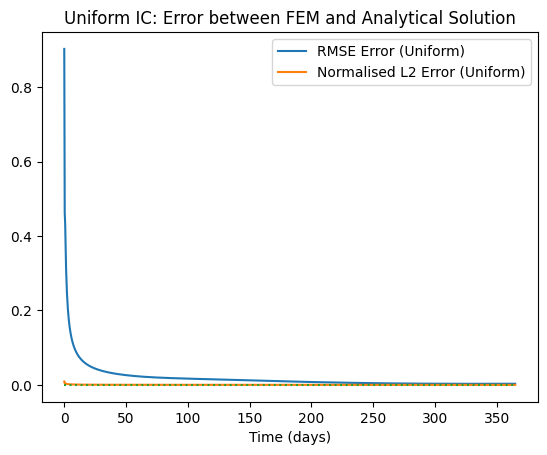

In [192]:
# Basic Test 1: Uniform initial condition (full time comparison)
N_terms_uniform = 200

analytical_cdata_u, analytical_udata_u, depth_u, time_u = Get_Terazaghi1d_Analytical(
    H, num, Load, T, time_steps, aCv, N_terms_uniform
)

analytical_udata_u = pd.DataFrame(analytical_udata_u, columns=-depth_u, index=time_u)
fem_udata_u = fem_udata.copy()

error_u = fem_udata_u.to_numpy() - analytical_udata_u.to_numpy()
RMSE_u = np.sqrt((error_u**2).mean(axis=1))
num_u = (error_u**2).sum(axis=1)
den_u = (analytical_udata_u.to_numpy()**2).sum(axis=1)
E_L2_u = np.sqrt(num_u / (den_u + 1e-12))

plt.figure()
plt.plot(time_u, RMSE_u, label="RMSE Error (Uniform)")
plt.plot(time_u, E_L2_u, label="Normalised L2 Error (Uniform)")
plt.plot([0, np.max(time_u)], [0, 0], linestyle="dotted")
plt.xlabel("Time (days)")
plt.legend()
plt.title("Uniform IC: Error between FEM and Analytical Solution")
plt.show()


/workspaces/Geotechnical-Consolidation-FEM-1/src/geotech_consolidation/models/terazaghi_multilayer/fem.py:200: RuntimeWarning: invalid value encountered in divide
  local_dcons = 1 - u_hist / u0[None,:]


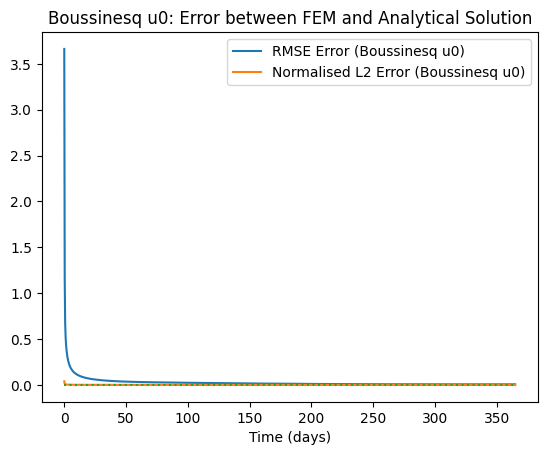

In [193]:
# Basic Test 2: Boussinesq initial condition (u0 analytical comparison)
N_terms_b = max(3, nodes // 2)

fem_cdata_b, fem_udata_b, settlement_b = Get_Terazaghi1dMultilayer_FEA(
    depths, num, Load, T, time_steps, Cv, Mv, Base=10, U0=False
)
fem_udata_b = pd.DataFrame(fem_udata_b, columns=Z, index=time)

u0_b = fem_udata_b.T[0]
analytical_udata_b, depth_b, time_b = Get_Terazaghi1d_Analytical_u0(
    u0_b, H, num, Load, T, time_steps, aCv, N_terms_b
)
analytical_udata_b = pd.DataFrame(analytical_udata_b, columns=-depth_b, index=time_b)

error_b = fem_udata_b.to_numpy() - analytical_udata_b.to_numpy()
RMSE_b = np.sqrt((error_b**2).mean(axis=1))
num_b = (error_b**2).sum(axis=1)
den_b = (analytical_udata_b.to_numpy()**2).sum(axis=1)
E_L2_b = np.sqrt(num_b / (den_b + 1e-12))

plt.figure()
plt.plot(time_b, RMSE_b, label="RMSE Error (Boussinesq u0)")
plt.plot(time_b, E_L2_b, label="Normalised L2 Error (Boussinesq u0)")
plt.plot([0, np.max(time_b)], [0, 0], linestyle="dotted")
plt.xlabel("Time (days)")
plt.legend()
plt.title("Boussinesq u0: Error between FEM and Analytical Solution")
plt.show()


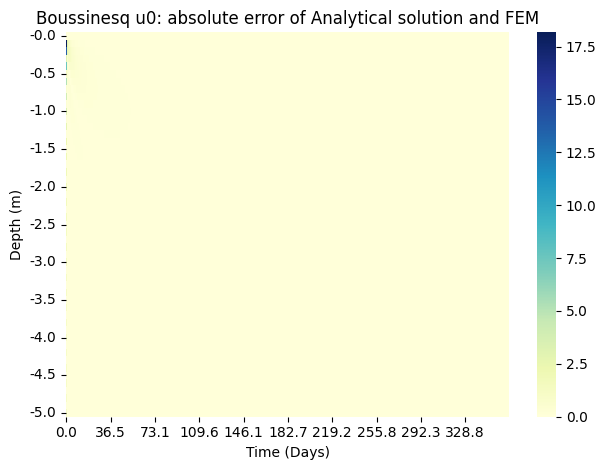

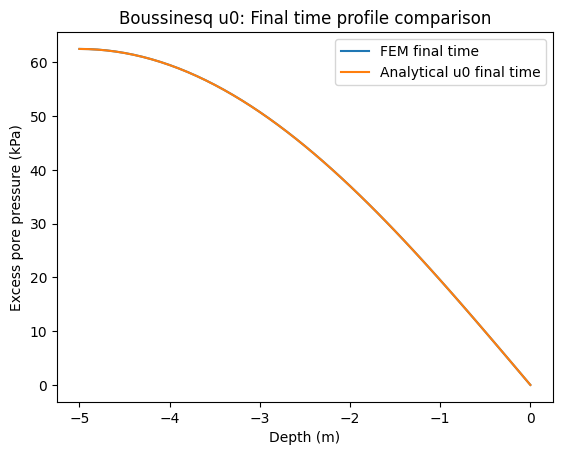

In [194]:
# For Boussinesq-u0, we focus on plotting error behavior and final-time depth profile
time_plot = time_b
depth_plot = Z

kx = max(1, len(time_plot)//10)    # ~8 labels across, auto
ky = max(1, len(depth_plot)//10)  # ~10 labels down, auto 


ax = sns.heatmap(abs(error_b).T, annot=False, cmap="YlGnBu", 
                 xticklabels=time_plot, yticklabels=depth_plot)

ax.set_xticks(np.arange(0, len(time_plot), kx) + 0.5)
ax.set_xticklabels([f"{time_plot[i]:.1f}" for i in range(0, len(time_plot), kx)],
                   rotation=0)

ax.set_yticks(np.arange(0, len(depth_plot), ky) + 0.5)
ax.set_yticklabels([f"{depth_plot[i]:.1f}" for i in range(0, len(depth_plot), ky)],
                   rotation=0)

ax.set_xlabel("Time (Days)")
ax.set_ylabel("Depth (m)")
ax.set_title("Boussinesq u0: absolute error of Analytical solution and FEM")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(Z, fem_udata_b.iloc[-1], label="FEM final time")
plt.plot(-depth_b, analytical_udata_b.iloc[-1], label="Analytical u0 final time")
plt.xlabel("Depth (m)")
plt.ylabel("Excess pore pressure (kPa)")
plt.title("Boussinesq u0: Final time profile comparison")
plt.legend()
plt.show()
